# (30) Curvature analysis: Lion vs. MassiveLion

device = ```cuda:1```

**Motivation**: <br>

In [1]:
# HIDE CODE


import os, pathlib
from IPython.display import display

# tmp & extras dir
_jb_dir = pathlib.Path(os.environ['HOME'])
_jb_dir /= 'Dropbox/git/jb-progress-2026'
extras_dir = _jb_dir / '_extras'
fig_base_dir = _jb_dir / 'figs'
tmp_dir = _jb_dir / 'tmp'

from gra.utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
## HIDE CODE


from gra.experiments.vision.models import WideResNet, ResNet18, ConvNet, MLP


def _ckpt_arg(ckpt, key, default=None):
    args = ckpt.get("args", {})
    return args.get(key, default) if isinstance(args, dict) else getattr(args, key, default)

def _clean_state_dict(sd):
    return {
        k.removeprefix("_orig_mod."): v
        for k, v in sd.items()
    }

def ckpt_to_vision_model(ckpt, device="cpu"):
    dataset = str(_ckpt_arg(ckpt, "dataset", "CIFAR10"))
    model_name = _ckpt_arg(ckpt, "model", "resnet")
    num_classes = 1000 if "imagenet" in dataset.lower() else 10

    model_cls = {
        "resnet": ResNet18,
        "wrn": WideResNet,
        "convnet": ConvNet,
        "mlp": MLP,
    }[model_name]

    model = model_cls(num_classes=num_classes).to(device)
    model.load_state_dict(_clean_state_dict(ckpt["model"]), strict=True)
    model.eval()
    return model

In [3]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## load runs

In [4]:
from gra.experiments.common.checkpointing import resolve_resume_source, load_checkpoint

run_paths = {
    "m_lion": "pal-lab/GRA-CIFAR10/ikft1odq",
    "lion": "pal-lab/GRA-CIFAR10/5ljlbsbj",
}

sources = {k: resolve_resume_source(v) for k, v in run_paths.items()}
ckpts = {
    k: load_checkpoint(src.checkpoint_path, map_location="cpu")
    for k, src in sources.items()
}

m_lion_ckpt = ckpts["m_lion"]
lion_ckpt = ckpts["lion"]

wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/hadi/.netrc.


In [5]:
m_lion_model = ckpt_to_vision_model(m_lion_ckpt)
lion_model = ckpt_to_vision_model(lion_ckpt)

,param_l2_norm
MassiveLion,69.383985
Lion,768.719726


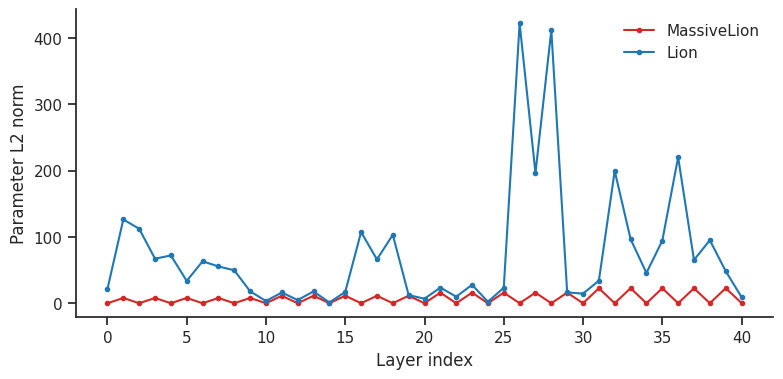

In [6]:
from gra.figures import optimizer_color


def _param_l2(params):
    return sum(p.detach().float().pow(2).sum().item() for p in params) ** 0.5

def model_param_norm(model):
    return _param_l2(model.parameters())

def layer_param_norms(model):
    rows = []
    for layer_idx, (name, module) in enumerate(
        (x for x in model.named_modules() if list(x[1].parameters(recurse=False)))
    ):
        params = list(module.parameters(recurse=False))
        rows.append((layer_idx, name, _param_l2(params)))
    return pd.DataFrame(rows, columns=["layer_idx", "layer", "norm"])

models = {
    "MassiveLion": m_lion_model,
    "Lion": lion_model,
}

overall_norms = pd.Series(
    {name: model_param_norm(model) for name, model in models.items()},
    name="param_l2_norm",
).to_frame()

display(overall_norms)

layer_norms = pd.concat([
    layer_param_norms(model).assign(optim=name)
    for name, model in models.items()
], ignore_index=True)

fig, ax = plt.subplots(figsize=(9, 4))
for name, df in layer_norms.groupby("optim", sort=False):
    ax.plot(
        df["layer_idx"], df["norm"],
        marker="o", ms=3, lw=1.5,
        color=optimizer_color(name),
        label=name,
    )

ax.set(xlabel="Layer index", ylabel="Parameter L2 norm")
ax.legend(frameon=False)
sns.despine()
plt.show()


## curvature metrics (unnormalized)

In [18]:
from types import SimpleNamespace

from gra.utils.dataset import make_dataloader
from gra.experiments.common.optim_factory import configure_optimizer
from gra.experiments.diagnostics.curvature_diagnostics import prepare_curvature_batch
from gra.experiments.diagnostics.diagnostic_logging import compute_final_curvature_outputs

CURVATURE_BATCH_SIZE = 2048
HUTCHINSON_SAMPLES = 32
LANCZOS_STEPS = 48
RANDOM_DIRS = 32

torch.manual_seed(0)

def _args_dict(ckpt):
    args = ckpt.get("args", {})
    return args if isinstance(args, dict) else vars(args)

def _arg(ckpt, *names, default=None):
    args = _args_dict(ckpt)
    for name in names:
        if name in args:
            return args[name]
    return default

def curvature_args(ckpt):
    return SimpleNamespace(
        optim=_arg(ckpt, "optim", "optimizer"),
        lr=_arg(ckpt, "lr", default=1e-3),
        wd=_arg(ckpt, "wd", "weight_decay", default=0.0),
        beta1=_arg(ckpt, "beta1", default=0.9),
        beta2=_arg(ckpt, "beta2", default=0.99),
        beta3=_arg(ckpt, "beta3", default=0.999),
        mass=_arg(ckpt, "mass", default=0.0),
        kappa=_arg(ckpt, "kappa", default=0.0),
        curvature_diagnostics=True,
        curvature_postfit=True,
        curvature_probe_batch_size=CURVATURE_BATCH_SIZE,
        curvature_hutchinson_samples=HUTCHINSON_SAMPLES,
        curvature_lanczos_steps=LANCZOS_STEPS,
        curvature_num_top_eigvecs=8,
        curvature_perturb_radii="1e-4,3e-4,1e-3,3e-3,1e-2",
        curvature_random_dirs=RANDOM_DIRS,
        curvature_slice_grid=0,   # metrics only; set >=3 if you want figs
        curvature_connectivity_ckpt="",
        curvature_ece_bins=15,
    )

def curvature_loss_fn(model, batch):
    x, y = batch
    return F.cross_entropy(model(x), y.long())

In [20]:
dataset = _arg(m_lion_ckpt, "dataset", default="CIFAR10")
_, val_loader = make_dataloader(dataset=dataset, batch_size=CURVATURE_BATCH_SIZE, device="cpu")
curvature_batch = prepare_curvature_batch(next(iter(val_loader)), device, CURVATURE_BATCH_SIZE)

models = {
    "m_lion": m_lion_model.to(device),
    "lion": lion_model.to(device),
}
ckpts = {
    "m_lion": m_lion_ckpt,
    "lion": lion_ckpt,
}

In [22]:
%%time


final_curvature = {}
for name, model in models.items():
    args = curvature_args(ckpts[name])
    optimizer = configure_optimizer(model, args, device)
    optimizer.load_state_dict(ckpts[name].get("optim_state", ckpts[name].get("optimizer")))

    model.zero_grad(set_to_none=True)
    curvature_loss_fn(model, curvature_batch).backward()

    metrics, figs = compute_final_curvature_outputs(
        model=model,
        optimizer=optimizer,
        batch=curvature_batch,
        loss_fn=curvature_loss_fn,
        args=args,
    )
    final_curvature[name] = metrics

Decay params: 11,164,352, No-decay params: 9,610
Optim: MassiveLion (
Parameter Group 0
    betas: (0.7, 0.99)
    lr: 0.001
    mass: 1.0
    weight_decay: 1.0

Parameter Group 1
    betas: (0.7, 0.99)
    lr: 0.001
    mass: 1.0
    weight_decay: 0.0
)
Decay params: 11,164,352, No-decay params: 9,610
Optim: MassiveLion (
Parameter Group 0
    betas: (0.9, 0.6)
    lr: 0.001
    mass: 0.0
    weight_decay: 1.0

Parameter Group 1
    betas: (0.9, 0.6)
    lr: 0.001
    mass: 0.0
    weight_decay: 0.0
)
CPU times: user 2min 15s, sys: 38.2 s, total: 2min 53s
Wall time: 2min 53s


In [25]:
final_curvature_df = pd.DataFrame(final_curvature).T
final_curvature_df

,probe_loss,probe_grad_norm,ece,calibration_confidence,calibration_accuracy,calibration_count,hessian_trace,hessian_trace_per_param,hessian_trace_std,lambda_max,...,sharpness_random_max_delta/r_1em04,sharpness_random_mean_delta/r_3em04,sharpness_random_max_delta/r_3em04,sharpness_random_mean_delta/r_1em03,sharpness_random_max_delta/r_1em03,sharpness_random_mean_delta/r_3em03,sharpness_random_max_delta/r_3em03,sharpness_random_mean_delta/r_1em02,sharpness_random_max_delta/r_1em02,sharpness_random_auc
m_lion,0.259231,314.024109,0.021052,0.946975,0.934570,2048.0,6.169792e+07,5.521580,2.274384e+07,6.196680e+06,...,0.001239,0.002171,0.004266,0.012819,0.024147,0.149485,0.264028,2.232827,2.666884,0.859184
lion,0.953175,13.051868,0.078248,0.985728,0.908203,2048.0,6.404906e+04,0.005732,2.869020e+04,1.009756e+04,...,0.000662,0.000703,0.001587,0.002584,0.006016,0.010457,0.020662,0.069994,0.125732,0.029885


## (1) filter-normalized adversarial sharpness

In [31]:
import copy
import math
import torch
import torch.nn.functional as F
from collections import OrderedDict

from gra.utils.dataset import make_dataloader

dataset = _ckpt_arg(m_lion_ckpt, "dataset", "CIFAR10")
batch_size = int(_ckpt_arg(m_lion_ckpt, "batch_size", 256))

train_loader, val_loader = make_dataloader(
    dataset=dataset,
    batch_size=batch_size,
    device=device,
)

loader = val_loader

m_lion_model = m_lion_model.to(device).eval()
lion_model = lion_model.to(device).eval()


def _batch_loss(model, x, y):
    out = model(x)
    if isinstance(out, tuple):
        out = out[0]
    return F.cross_entropy(out, y.long())


def _eval_loss_acc(model, loader, max_batches=20):
    model.eval()
    total_loss = total_correct = total_n = 0
    with torch.no_grad():
        for bi, (x, y) in enumerate(loader):
            if bi >= max_batches:
                break
            x, y = x.to(device), y.to(device)
            logits = model(x)
            if isinstance(logits, tuple):
                logits = logits[0]
            loss = F.cross_entropy(logits, y.long(), reduction="sum")
            total_loss += loss.item()
            total_correct += logits.argmax(1).eq(y).sum().item()
            total_n += y.numel()
    return total_loss / total_n, total_correct / total_n


def _filter_norms(param, eps=1e-12):
    # Per-output-filter norm for conv/linear weights; scalar/bias gets abs value.
    if param.ndim <= 1:
        return param.detach().abs().clamp_min(eps)
    return param.detach().flatten(1).norm(dim=1).clamp_min(eps).view(
        -1, *([1] * (param.ndim - 1))
    )


def _init_filter_normalized_delta(model):
    delta = OrderedDict()
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        d = torch.randn_like(p)
        d = d * (_filter_norms(p) / _filter_norms(d))
        delta[name] = d
    return delta


def _delta_norm(delta, model):
    # Norm in filter-normalized coordinates: || delta / ||filter|| ||_2.
    sq = 0.0
    params = dict(model.named_parameters())
    for name, d in delta.items():
        scale = _filter_norms(params[name])
        sq = sq + ((d / scale) ** 2).sum()
    return sq.sqrt()


def _project_delta_(delta, model, rho):
    norm = _delta_norm(delta, model)
    if norm > rho:
        scale = rho / (norm + 1e-12)
        for d in delta.values():
            d.mul_(scale)


def _add_delta_(model, delta, alpha=1.0):
    with torch.no_grad():
        for name, p in model.named_parameters():
            if name in delta:
                p.add_(delta[name], alpha=alpha)


def filter_normalized_adversarial_sharpness(
    model,
    loader,
    rho=1.0,
    ascent_steps=10,
    ascent_lr=None,
    max_batches=20,
):
    """
    Returns max_{||delta/filter_norm(theta)|| <= rho}
        loss(theta + delta) - loss(theta)

    This is the Li et al. filter-normalized neighborhood, optimized with
    projected gradient ascent, so it is much less sensitive to raw weight scale.
    """
    model = copy.deepcopy(model).to(device).eval()

    base_loss, base_acc = _eval_loss_acc(model, loader, max_batches=max_batches)
    delta = _init_filter_normalized_delta(model)
    _project_delta_(delta, model, rho)

    if ascent_lr is None:
        ascent_lr = rho / max(1, ascent_steps // 2)

    batches = []
    for bi, batch in enumerate(loader):
        if bi >= max_batches:
            break
        x, y = batch
        batches.append((x.to(device), y.to(device)))

    for _ in range(ascent_steps):
        _add_delta_(model, delta, alpha=1.0)

        for p in model.parameters():
            p.grad = None

        loss = 0.0
        n = 0
        for x, y in batches:
            batch_loss = _batch_loss(model, x, y)
            loss = loss + batch_loss * y.numel()
            n += y.numel()
        loss = loss / n
        loss.backward()

        _add_delta_(model, delta, alpha=-1.0)

        with torch.no_grad():
            for name, p in model.named_parameters():
                if name not in delta or p.grad is None:
                    continue
                g = p.grad
                # Gradient ascent in filter-normalized coordinates.
                scale = _filter_norms(p)
                delta[name].add_(g * scale.square(), alpha=ascent_lr)
            _project_delta_(delta, model, rho)

    _add_delta_(model, delta, alpha=1.0)
    sharp_loss, sharp_acc = _eval_loss_acc(model, loader, max_batches=max_batches)
    _add_delta_(model, delta, alpha=-1.0)

    return {
        "base_loss": base_loss,
        "base_acc": base_acc,
        "sharp_loss": sharp_loss,
        "sharp_acc": sharp_acc,
        "sharpness": sharp_loss - base_loss,
        "relative_sharpness": (sharp_loss - base_loss) / (base_loss + 1e-12),
        "rho": rho,
        "ascent_steps": ascent_steps,
        "max_batches": max_batches,
    }

In [32]:
results = {}
for name, model in {
    "m_lion": m_lion_model,
    "lion": lion_model,
}.items():
    results[name] = filter_normalized_adversarial_sharpness(
        model,
        loader,
        rho=1.0,
        ascent_steps=10,
        max_batches=20,
    )

results

{'m_lion': {'base_loss': 0.2558911100029945,
  'base_acc': 0.9349609375,
  'sharp_loss': 83.08757057189942,
  'sharp_acc': 0.098828125,
  'sharpness': 82.83167946189643,
  'relative_sharpness': 323.6989337402281,
  'rho': 1.0,
  'ascent_steps': 10,
  'max_batches': 20},
 'lion': {'base_loss': 1.0035116523504257,
  'base_acc': 0.9017578125,
  'sharp_loss': 4.837953176277615e+17,
  'sharp_acc': 0.10078125,
  'sharpness': 4.837953176277615e+17,
  'relative_sharpness': 4.8210234180553216e+17,
  'rho': 1.0,
  'ascent_steps': 10,
  'max_batches': 20}}

In [33]:
rhos = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1]

sharpness_sweep = {}
for rho in rhos:
    sharpness_sweep[rho] = {
        name: filter_normalized_adversarial_sharpness(
            model,
            loader,
            rho=rho,
            ascent_steps=10,
            max_batches=20,
        )
        for name, model in {
            "m_lion": m_lion_model,
            "lion": lion_model,
        }.items()
    }

for rho, res in sharpness_sweep.items():
    print(f"\nrho={rho:g}")
    for name, r in res.items():
        print(
            name,
            "base_loss", r["base_loss"],
            "sharp_loss", r["sharp_loss"],
            "sharpness", r["sharpness"],
            "base_acc", r["base_acc"],
            "sharp_acc", r["sharp_acc"],
        )


rho=0.0001

m_lion base_loss 0.2558911100029945 sharp_loss 0.25599602088332174 sharpness 0.00010491088032721363 base_acc 
0.9349609375 sharp_acc 0.93515625

lion base_loss 1.0035116523504257 sharp_loss 1.0080619752407074 sharpness 0.004550322890281677 base_acc 
0.9017578125 sharp_acc 0.9015625

rho=0.0003

m_lion base_loss 0.2558911100029945 sharp_loss 0.25619818568229674 sharpness 0.0003070756793022156 base_acc 
0.9349609375 sharp_acc 0.9349609375

...

m_lion base_loss 0.2558911100029945 sharp_loss 2.0493740022182463 sharpness 1.7934828922152517 base_acc 
0.9349609375 sharp_acc 0.5494140625

lion base_loss 1.0035116523504257 sharp_loss 128872773632.0 sharpness 128872773630.99649 base_acc 0.9017578125 
sharp_acc 0.10078125

rho=0.3

m_lion base_loss 0.2558911100029945 sharp_loss 9.961841917037964 sharpness 9.705950807034968 base_acc 0.9349609375 
sharp_acc 0.098828125

lion base_loss 1.0035116523504257 sharp_loss 64390617785958.4 sharpness 64390617785957.4 base_acc 0.9017578125 
sharp_acc 0.10078125

## (2) function-space KL sensitivity

In [8]:
from gra.utils.dataset import make_dataloader

dataset = _ckpt_arg(m_lion_ckpt, "dataset", "CIFAR10")
batch_size = int(_ckpt_arg(m_lion_ckpt, "batch_size", 256))

train_loader, val_loader = make_dataloader(
    dataset=dataset,
    batch_size=batch_size,
    device=device,
)

loader = val_loader

In [13]:
import copy
import torch
import torch.nn.functional as F
from collections import OrderedDict


def _logits(model, x):
    out = model(x)
    return out[0] if isinstance(out, tuple) else out


def _filter_norms(param, eps=1e-12):
    if param.ndim <= 1:
        return param.detach().abs().clamp_min(eps)
    return param.detach().flatten(1).norm(dim=1).clamp_min(eps).view(
        -1, *([1] * (param.ndim - 1))
    )


def _init_delta(model):
    delta = OrderedDict()
    for name, p in model.named_parameters():
        if p.requires_grad:
            d = torch.randn_like(p)
            d = d * (_filter_norms(p) / _filter_norms(d))
            delta[name] = d
    return delta


def _delta_norm(delta, model):
    sq = 0.0
    params = dict(model.named_parameters())
    for name, d in delta.items():
        sq = sq + ((d / _filter_norms(params[name])) ** 2).sum()
    return sq.sqrt()


def _project_delta_(delta, model, rho):
    n = _delta_norm(delta, model)
    if n > rho:
        s = rho / (n + 1e-12)
        for d in delta.values():
            d.mul_(s)


def _add_delta_(model, delta, alpha=1.0):
    with torch.no_grad():
        for name, p in model.named_parameters():
            if name in delta:
                p.add_(delta[name], alpha=alpha)


@torch.no_grad()
def _base_probs(model, batches):
    probs = []
    losses = []
    accs = []
    n_total = 0

    for x, y in batches:
        z = _logits(model, x)
        p = z.softmax(dim=1)
        probs.append(p.detach())

        losses.append(F.cross_entropy(z, y.long(), reduction="sum").item())
        accs.append(z.argmax(1).eq(y).sum().item())
        n_total += y.numel()

    return {
        "probs": probs,
        "loss": sum(losses) / n_total,
        "acc": sum(accs) / n_total,
    }


def _mean_kl_to_base(model, batches, base_probs):
    total_kl = 0.0
    total_n = 0

    for (x, y), p0 in zip(batches, base_probs):
        z = _logits(model, x)
        logp = F.log_softmax(z, dim=1)
        kl = (p0 * (p0.clamp_min(1e-12).log() - logp)).sum(dim=1)
        total_kl = total_kl + kl.sum()
        total_n += x.shape[0]

    return total_kl / total_n


@torch.no_grad()
def _eval_after_delta(model, batches, base_probs):
    total_kl = 0.0
    total_loss = 0.0
    total_correct = 0
    total_n = 0

    for (x, y), p0 in zip(batches, base_probs):
        z = _logits(model, x)
        logp = F.log_softmax(z, dim=1)
        kl = (p0 * (p0.clamp_min(1e-12).log() - logp)).sum(dim=1)

        total_kl += kl.sum().item()
        total_loss += F.cross_entropy(z, y.long(), reduction="sum").item()
        total_correct += z.argmax(1).eq(y).sum().item()
        total_n += y.numel()

    return {
        "kl": total_kl / total_n,
        "loss": total_loss / total_n,
        "acc": total_correct / total_n,
    }


def filter_normalized_adversarial_kl(
    model,
    loader,
    rho=1e-3,
    ascent_steps=10,
    ascent_lr=None,
    max_batches=20,
):
    model = copy.deepcopy(model).to(device).eval()

    batches = []
    for bi, (x, y) in enumerate(loader):
        if bi >= max_batches:
            break
        batches.append((x.to(device), y.to(device)))

    base = _base_probs(model, batches)
    delta = _init_delta(model)
    _project_delta_(delta, model, rho)

    if ascent_lr is None:
        ascent_lr = rho / max(1, ascent_steps // 2)

    for _ in range(ascent_steps):
        _add_delta_(model, delta, alpha=1.0)

        for p in model.parameters():
            p.grad = None

        kl = _mean_kl_to_base(model, batches, base["probs"])
        kl.backward()

        _add_delta_(model, delta, alpha=-1.0)

        with torch.no_grad():
            for name, p in model.named_parameters():
                if name not in delta or p.grad is None:
                    continue
                scale = _filter_norms(p)
                delta[name].add_(p.grad * scale.square(), alpha=ascent_lr)
            _project_delta_(delta, model, rho)

    _add_delta_(model, delta, alpha=1.0)
    pert = _eval_after_delta(model, batches, base["probs"])
    _add_delta_(model, delta, alpha=-1.0)

    return {
        "base_loss": base["loss"],
        "base_acc": base["acc"],
        "pert_loss": pert["loss"],
        "pert_acc": pert["acc"],
        "kl": pert["kl"],
        "rho": rho,
        "ascent_steps": ascent_steps,
        "max_batches": max_batches,
    }

In [14]:
rhos = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2]

kl_sweep = {}
for rho in rhos:
    kl_sweep[rho] = {
        name: filter_normalized_adversarial_kl(
            model,
            loader,
            rho=rho,
            ascent_steps=10,
            max_batches=20,
        )
        for name, model in {
            "m_lion": m_lion_model,
            "lion": lion_model,
        }.items()
    }

for rho, res in kl_sweep.items():
    print(f"\nrho={rho:g}")
    for name, r in res.items():
        print(
            name,
            "KL", r["kl"],
            "base_acc", r["base_acc"],
            "pert_acc", r["pert_acc"],
            "base_loss", r["base_loss"],
            "pert_loss", r["pert_loss"],
        )


rho=0.0001

m_lion KL 2.412677955199172e-08 base_acc 0.9349609375 pert_acc 0.9349609375 base_loss 0.2558911100029945 pert_loss 
0.255889481306076

lion KL 0.0009067543447599747 base_acc 0.9017578125 pert_acc 0.9017578125 base_loss 1.0035116523504257 pert_loss 
1.0023676186800003

rho=0.0003

m_lion KL 2.7042593075954356e-08 base_acc 0.9349609375 pert_acc 0.9349609375 base_loss 0.2558911100029945 pert_loss
0.25589281395077706

...

m_lion KL 7.598999377478321e-06 base_acc 0.9349609375 pert_acc 0.93515625 base_loss 0.2558911100029945 pert_loss 
0.25607799738645554

lion KL 3.878254699707031 base_acc 0.9017578125 pert_acc 0.6380859375 base_loss 1.0035116523504257 pert_loss 
4.325893342494965

rho=0.03

m_lion KL 0.03587683262303472 base_acc 0.9349609375 pert_acc 0.924609375 base_loss 0.2558911100029945 pert_loss 
0.28081557154655457

lion KL 57982259200.0 base_acc 0.9017578125 pert_acc 0.10078125 base_loss 1.0035116523504257 pert_loss 
58549454438.4

## (3) thermal weight-noise susceptibility

In [7]:
from gra.utils.dataset import make_dataloader

dataset = _ckpt_arg(m_lion_ckpt, "dataset", "CIFAR10")
batch_size = int(_ckpt_arg(m_lion_ckpt, "batch_size", 256))

train_loader, val_loader = make_dataloader(
    dataset=dataset,
    batch_size=batch_size,
    device=device,
)

loader = val_loader

In [8]:
import copy
import torch
import torch.nn.functional as F
from collections import OrderedDict


def _logits(model, x):
    z = model(x)
    return z[0] if isinstance(z, tuple) else z


def _filter_norms(param, eps=1e-12):
    if param.ndim <= 1:
        return param.detach().abs().clamp_min(eps)
    return param.detach().flatten(1).norm(dim=1).clamp_min(eps).view(
        -1, *([1] * (param.ndim - 1))
    )


def _random_filter_normalized_delta(model, rho):
    delta = OrderedDict()
    sq = 0.0

    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        scale = _filter_norms(p)
        u = torch.randn_like(p)
        d = u * scale
        delta[name] = d
        sq = sq + ((d / scale) ** 2).sum()

    norm = sq.sqrt()
    for d in delta.values():
        d.mul_(rho / (norm + 1e-12))

    return delta


def _add_delta_(model, delta, alpha=1.0):
    with torch.no_grad():
        for name, p in model.named_parameters():
            if name in delta:
                p.add_(delta[name], alpha=alpha)


@torch.no_grad()
def _base_state(model, batches):
    probs = []
    total_loss = 0.0
    total_correct = 0
    total_n = 0

    for x, y in batches:
        y = y.long()
        z = _logits(model, x)
        p = z.softmax(dim=1)
        probs.append(p.detach())

        total_loss += F.cross_entropy(z, y.long(), reduction="sum").item()
        total_correct += z.argmax(1).eq(y).sum().item()
        total_n += y.numel()

    return {
        "probs": probs,
        "loss": total_loss / total_n,
        "acc": total_correct / total_n,
    }


@torch.no_grad()
def _eval_thermal_sample(model, batches, base_probs):
    total_kl = 0.0
    total_loss = 0.0
    total_correct = 0
    total_n = 0

    for (x, y), p0 in zip(batches, base_probs):
        y = y.long()
        z = _logits(model, x)
        logp = F.log_softmax(z, dim=1)

        kl = (p0 * (p0.clamp_min(1e-12).log() - logp)).sum(dim=1)
        total_kl += kl.sum().item()
        total_loss += F.cross_entropy(z, y.long(), reduction="sum").item()
        total_correct += z.argmax(1).eq(y).sum().item()
        total_n += y.numel()

    return {
        "kl": total_kl / total_n,
        "loss": total_loss / total_n,
        "acc": total_correct / total_n,
    }


def filter_normalized_thermal_susceptibility(
    model,
    loader,
    rho=1e-2,
    samples=20,
    max_batches=20,
):
    model = copy.deepcopy(model).to(device).eval()

    batches = []
    for bi, (x, y) in enumerate(loader):
        if bi >= max_batches:
            break
        batches.append((x.to(device), y.to(device)))

    base = _base_state(model, batches)
    vals = []

    for _ in range(samples):
        delta = _random_filter_normalized_delta(model, rho)
        _add_delta_(model, delta, alpha=1.0)
        vals.append(_eval_thermal_sample(model, batches, base["probs"]))
        _add_delta_(model, delta, alpha=-1.0)

    kl = torch.tensor([v["kl"] for v in vals])
    loss = torch.tensor([v["loss"] for v in vals])
    acc = torch.tensor([v["acc"] for v in vals])

    return {
        "base_loss": base["loss"],
        "base_acc": base["acc"],
        "mean_kl": kl.mean().item(),
        "std_kl": kl.std(unbiased=False).item(),
        "p95_kl": kl.quantile(0.95).item(),
        "mean_loss": loss.mean().item(),
        "mean_loss_increase": (loss.mean().item() - base["loss"]),
        "p95_loss_increase": (loss.quantile(0.95).item() - base["loss"]),
        "mean_acc": acc.mean().item(),
        "worst_acc": acc.min().item(),
        "rho": rho,
        "samples": samples,
        "max_batches": max_batches,
    }

In [9]:
rhos = [1e-3, 3e-3, 1e-2, 3e-2, 1e-1]

thermal_sweep = {}
for rho in rhos:
    thermal_sweep[rho] = {
        name: filter_normalized_thermal_susceptibility(
            model,
            loader,
            rho=rho,
            samples=30,
            max_batches=20,
        )
        for name, model in {
            "m_lion": m_lion_model,
            "lion": lion_model,
        }.items()
    }

for rho, res in thermal_sweep.items():
    print(f"\nrho={rho:g}")
    for name, r in res.items():
        print(
            name,
            "mean_KL", r["mean_kl"],
            "p95_KL", r["p95_kl"],
            "mean_loss_inc", r["mean_loss_increase"],
            "p95_loss_inc", r["p95_loss_increase"],
            "base_acc", r["base_acc"],
            "mean_acc", r["mean_acc"],
            "worst_acc", r["worst_acc"],
        )


rho=0.001

m_lion mean_KL 2.9301441273332784e-08 p95_KL 3.321693853308716e-08 mean_loss_inc -4.7236680983386847e-07 
p95_loss_inc 3.67015600205578e-06 base_acc 0.9349609375 mean_acc 0.9349607825279236 worst_acc 0.9349609613418579

lion mean_KL 3.944095396946068e-07 p95_KL 4.649065488138149e-07 mean_loss_inc -1.309812068939209e-05 p95_loss_inc 
1.6227364540100098e-05 base_acc 0.9017578125 mean_acc 0.9017576575279236 worst_acc 0.9017578363418579

rho=0.003

m_lion mean_KL 3.875713971979167e-08 p95_KL 4.5319346497763036e-08 mean_loss_inc -1.8432736396678528e-06 
p95_loss_inc 3.8191676139942565e-06 base_acc 0.9349609375 mean_acc 0.9349673986434937 worst_acc 0.9349609613418579

...

m_lion mean_KL 1.5803580311057885e-07 p95_KL 2.068513538233674e-07 mean_loss_inc 9.8988413810841e-06 p95_loss_inc 
3.1684339046489374e-05 base_acc 0.9349609375 mean_acc 0.9350651502609253 worst_acc 0.934765636920929

lion mean_KL 5.842546670464799e-05 p95_KL 7.57106754463166e-05 mean_loss_inc -3.431737422943115e-05 p95_loss_inc 
0.00045336782932281494 base_acc 0.9017578125 mean_acc 0.9019270539283752 worst_acc 0.901562511920929

rho=0.1

m_lion mean_KL 9.831775287238997e-07 p95_KL 1.3952745803180733e-06 mean_loss_inc 1.365393400193371e-05 p95_loss_inc
6.610602140427746e-05 base_acc 0.9349609375 mean_acc 0.9350391030311584 worst_acc 0.934765636920929

lion mean_KL 0.0006202550139278173 p95_KL 0.0008416072814725339 mean_loss_inc 3.2082200050354004e-05 p95_loss_inc 
0.0021755844354629517 base_acc 0.9017578125 mean_acc 0.9019336700439453 worst_acc 0.900585949420929

## (4) normal-mode spectrum of the filter-normalized Fisher/KL stiffness matrix

In [11]:
from gra.utils.dataset import make_dataloader

dataset = _ckpt_arg(m_lion_ckpt, "dataset", "CIFAR10")
batch_size = int(_ckpt_arg(m_lion_ckpt, "batch_size", 256))

train_loader, val_loader = make_dataloader(
    dataset=dataset,
    batch_size=batch_size,
    device=device,
)

loader = val_loader

In [12]:
import copy
import torch
import torch.nn.functional as F


def _logits(model, x):
    z = model(x)
    return z[0] if isinstance(z, tuple) else z


def _filter_norms(param, eps=1e-12):
    if param.ndim <= 1:
        return param.detach().abs().clamp_min(eps)
    return param.detach().flatten(1).norm(dim=1).clamp_min(eps).view(
        -1, *([1] * (param.ndim - 1))
    )


def _flatten(tensors):
    return torch.cat([t.reshape(-1) for t in tensors])


def _unflatten_like(flat, params):
    out = []
    i = 0
    for p in params:
        n = p.numel()
        out.append(flat[i:i+n].view_as(p))
        i += n
    return out


def _unit(v, eps=1e-12):
    return v / (v.norm() + eps)


@torch.no_grad()
def _collect_batches_and_base(model, loader, max_batches):
    batches = []
    base_probs = []
    total_loss = 0.0
    total_correct = 0
    total_n = 0

    for bi, (x, y) in enumerate(loader):
        if bi >= max_batches:
            break
        x = x.to(device)
        y = y.to(device).long()
        z = _logits(model, x)
        p = z.softmax(dim=1).detach()

        batches.append((x, y))
        base_probs.append(p)

        total_loss += F.cross_entropy(z, y.long(), reduction="sum").item()
        total_correct += z.argmax(1).eq(y).sum().item()
        total_n += y.numel()

    return {
        "batches": batches,
        "base_probs": base_probs,
        "base_loss": total_loss / total_n,
        "base_acc": total_correct / total_n,
        "n_examples": total_n,
    }


def _mean_kl_graph(model, batches, base_probs):
    total = 0.0
    total_n = 0

    for (x, y), p0 in zip(batches, base_probs):
        z = _logits(model, x)
        logp = F.log_softmax(z, dim=1)
        kl = (p0 * (p0.clamp_min(1e-12).log() - logp)).sum(dim=1)
        total = total + kl.sum()
        total_n += x.shape[0]

    return total / total_n


def filter_normalized_fisher_normal_modes(
    model,
    loader,
    max_batches=10,
    lanczos_steps=12,
    random_probes=8,
):
    """
    Estimates spectrum of S F S, where F is the predictive Fisher/KL Hessian
    and S maps normalized filter coordinates to real parameter coordinates.

    Eigenvalues are functional stiffness constants in filter-normalized
    parameter coordinates.
    """
    model = copy.deepcopy(model).to(device).eval()
    state = _collect_batches_and_base(model, loader, max_batches=max_batches)

    params = [p for p in model.parameters() if p.requires_grad]
    scales = [_filter_norms(p).detach() for p in params]
    n_dim = sum(p.numel() for p in params)

    def matvec(q_flat):
        q_parts = _unflatten_like(q_flat.to(device), params)
        real_vec = [q * s for q, s in zip(q_parts, scales)]

        for p in params:
            p.grad = None

        kl = _mean_kl_graph(model, state["batches"], state["base_probs"])
        grads = torch.autograd.grad(
            kl,
            params,
            create_graph=True,
            retain_graph=True,
            allow_unused=True,
        )
        grads = [
            torch.zeros_like(p) if g is None else g
            for g, p in zip(grads, params)
        ]

        dot = sum((g * v).sum() for g, v in zip(grads, real_vec))
        hv = torch.autograd.grad(
            dot,
            params,
            retain_graph=False,
            allow_unused=True,
        )
        hv = [
            torch.zeros_like(p) if h is None else h
            for h, p in zip(hv, params)
        ]

        # Return S F S q, i.e. stiffness in normalized coordinates.
        return _flatten([h * s for h, s in zip(hv, scales)]).detach()

    # Random Rayleigh probes estimate typical stiffness = trace(F_norm) / dim.
    rayleigh = []
    for _ in range(random_probes):
        q = _unit(torch.randn(n_dim, device=device))
        hq = matvec(q)
        rayleigh.append(torch.dot(q, hq).item())

    # Lanczos for top normal modes.
    q = _unit(torch.randn(n_dim, device=device))
    q_prev = torch.zeros_like(q)
    Q = []
    alphas = []
    betas = []
    beta = 0.0

    for k in range(lanczos_steps):
        w = matvec(q)
        if k > 0:
            w = w - beta * q_prev

        alpha = torch.dot(q, w)
        w = w - alpha * q

        # Full reorthogonalization, cheap relative to HVP cost.
        for qi in Q:
            w = w - torch.dot(qi, w) * qi

        beta_next = w.norm()
        Q.append(q)
        alphas.append(alpha.item())

        if beta_next.item() < 1e-10:
            break

        if k < lanczos_steps - 1:
            betas.append(beta_next.item())
            q_prev = q
            q = w / beta_next
            beta = beta_next

    m = len(alphas)
    T = torch.zeros(m, m, device=device)
    for i, a in enumerate(alphas):
        T[i, i] = a
    for i, b in enumerate(betas[:m-1]):
        T[i, i+1] = b
        T[i+1, i] = b

    eigs = torch.linalg.eigvalsh(T).detach().cpu()
    eigs_sorted = eigs.sort(descending=True).values

    random_mean = float(torch.tensor(rayleigh).mean().item())
    random_std = float(torch.tensor(rayleigh).std(unbiased=False).item())
    lambda_max = float(eigs_sorted[0].item())

    return {
        "base_loss": state["base_loss"],
        "base_acc": state["base_acc"],
        "n_examples": state["n_examples"],
        "n_params": n_dim,
        "lambda_max": lambda_max,
        "top_eigs": eigs_sorted[: min(8, len(eigs_sorted))].tolist(),
        "random_rayleigh_mean": random_mean,
        "random_rayleigh_std": random_std,
        "stiff_mode_ratio": lambda_max / (random_mean + 1e-30),
        "lanczos_steps": lanczos_steps,
        "random_probes": random_probes,
        "max_batches": max_batches,
    }


In [13]:
normal_modes = {
    name: filter_normalized_fisher_normal_modes(
        model,
        loader,
        max_batches=10,
        lanczos_steps=12,
        random_probes=8,
    )
    for name, model in {
        "m_lion": m_lion_model,
        "lion": lion_model,
    }.items()
}

normal_modes

{'m_lion': {'base_loss': 0.2614572897553444,
  'base_acc': 0.934765625,
  'n_examples': 2560,
  'n_params': 11173962,
  'lambda_max': 168.32254028320312,
  'top_eigs': [168.32254028320312,
   154.75204467773438,
   128.15802001953125,
   120.26842498779297,
   86.55966186523438,
   75.37566375732422,
   54.98479080200195,
   43.09144592285156],
  'random_rayleigh_mean': 0.00014478989760391414,
  'random_rayleigh_std': 3.249426299589686e-05,
  'stiff_mode_ratio': 1162529.589900427,
  'lanczos_steps': 12,
  'random_probes': 8,
  'max_batches': 10},
 'lion': {'base_loss': 1.0170745313167573,
  'base_acc': 0.9015625,
  'n_examples': 2560,
  'n_params': 11173962,
  'lambda_max': 225088.625,
  'top_eigs': [225088.625,
   89030.21875,
   68391.0,
   65864.078125,
   46158.95703125,
   34981.203125,
   29042.904296875,
   18744.001953125],
  'random_rayleigh_mean': 0.12634176015853882,
  'random_rayleigh_std': 0.02691529504954815,
  'stiff_mode_ratio': 1781585.3184058033,
  'lanczos_steps': 12